## Exercice 1.1 : Réduction de dimension avec PCA
Dans cet atelier, nous réduisons manuellement le nombre de dimensions d'un trafic réseau sans étiquettes pour observer la structure globale des flux.

#### 1. Chargement et encodage des données

In [1]:
import pandas as pd

# Chargement du trafic réseau sans étiquette
data = pd.read_csv('data/UNSW_NB15_training-set.csv')
print("Dimensions :", data.shape)
data.head()

Dimensions : (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [2]:
# Encodage des catégories - On transofrme du texte en numéro par exemple pour UDP
from sklearn.preprocessing import LabelEncoder

features = data.copy()
for col in features.select_dtypes(include=['object']).columns:
    features[col] = LabelEncoder().fit_transform(features[col].astype(str))

features.head()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_32348\801156191.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in features.select_dtypes(include=['object']).columns:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,117,0,4,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,6,0
1,2,0.000008,117,0,4,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,6,0
2,3,0.000005,117,0,4,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,6,0
3,4,0.000006,117,0,4,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,6,0
4,5,0.000010,117,0,4,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,6,0


#### 2. Réduire la dimensionalité des données brutes

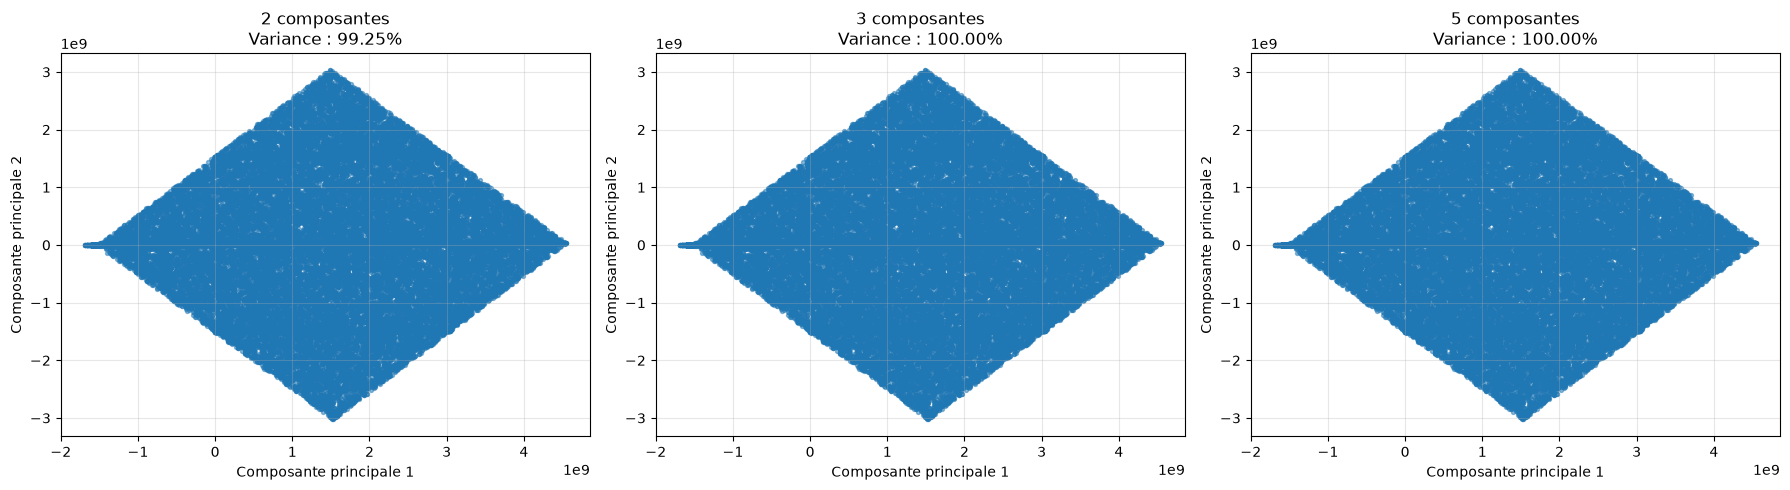

In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Choisissez les trois dimensions à comparer
components_to_test = [2, 3, 5]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, n in zip(axes, components_to_test):
    pca = PCA(n_components=n, random_state=42)
    X_pca_current = pca.fit_transform(features)
    variance_pct = pca.explained_variance_ratio_.sum() * 100
    ax.scatter(
        X_pca_current[:, 0],
        X_pca_current[:, 1],
        s=8,
        alpha=0.5
    )
    ax.set_title(f"{n} composantes\nVariance : {variance_pct:.2f}%")
    ax.set_xlabel("Composante principale 1")
    ax.set_ylabel("Composante principale 2")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Tu remarques que la variance est extrêmement élevée (99,25% dès 2 composantes). C'est un comportement suspect en IA. Si tu regardes les axes, les valeurs vont de $-3 \times 10^9$ à $4 \times 10^9$ (des milliards !).Comme tes données n'ont pas encore été normalisées, certaines features qui ont des valeurs géantes (comme sload ou dload qui mesurent des bits par seconde) écrasent complètement les autres variables (comme duration qui vaut souvent moins de 1 seconde). La PCA s'est concentrée uniquement sur ces variables géantes, créant cette forme de losange parfaite, mais elle passe à côté des informations plus subtiles de ton trafic réseau.

Composante 1 : 80.6262% de variance expliquée (cumul : 80.6262%)
Composante 2 : 18.6192% de variance expliquée (cumul : 99.2454%)
Composante 3 : 0.7545% de variance expliquée (cumul : 99.9999%)
Composante 4 : 0.0001% de variance expliquée (cumul : 100.0000%)
Composante 5 : 0.0000% de variance expliquée (cumul : 100.0000%)


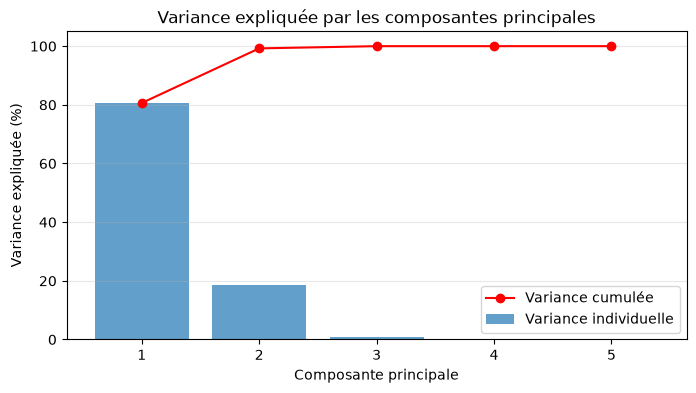

In [4]:
# Chaque composante principale est une combinaison linéaire des variables initiales.
# La variance expliquée mesure la proportion d'information conservée par chaque composante.

variance = pca.explained_variance_ratio_ * 100
variance_cumulee = variance.cumsum()

for i, (v, vc) in enumerate(zip(variance, variance_cumulee), start=1):
    print(
        f"Composante {i} : {v:.4f}% de variance expliquée "
        f"(cumul : {vc:.4f}%)"
    )

# Visualisation de la variance expliquée
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(variance) + 1), variance, alpha=0.7, label="Variance individuelle")
plt.plot(range(1, len(variance_cumulee) + 1), variance_cumulee, "o-", color="red",label="Variance cumulée")
plt.xlabel("Composante principale")
plt.ylabel("Variance expliquée (%)")
plt.title("Variance expliquée par les composantes principales")
plt.xticks(range(1, len(variance) + 1))
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.show()

In [5]:
# Variables contribuant le plus à chaque composante
for i, coefficients in enumerate(pca.components_, start=1):
    contributions = pd.Series(coefficients, index=features.columns)
    principales = contributions.abs().sort_values(ascending=False).head(5)
    print(f"\nComposante {i} — variables principales :")
    print(principales.index.tolist())


Composante 1 — variables principales :
['stcpb', 'dtcpb', 'sload', 'dload', 'rate']

Composante 2 — variables principales :
['dtcpb', 'stcpb', 'dload', 'sload', 'sbytes']

Composante 3 — variables principales :
['sload', 'stcpb', 'dtcpb', 'dload', 'rate']

Composante 4 — variables principales :
['dload', 'dbytes', 'rate', 'id', 'sjit']

Composante 5 — variables principales :
['sbytes', 'dbytes', 'rate', 'response_body_len', 'sjit']


#### 3. Réduction avec normalisation des données

In [6]:
# Pourquoi normaliser ? Observons les données brutes --> On a trop de variance ce aui peut fausser les résultats
features.describe()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
count,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,8.233200e+04,8.233200e+04,8.233200e+04,...,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000,82332.000000
mean,41166.500000,1.006756,109.348273,1.421695,3.374751,18.666472,17.545936,7.993908e+03,1.323379e+04,8.241089e+04,...,3.663011,7.456360,0.008284,0.008381,0.129743,6.468360,9.164262,0.011126,4.987757,0.550600
std,23767.345519,4.710444,18.637282,2.108083,0.670372,133.916353,115.574086,1.716423e+05,1.514715e+05,1.486204e+05,...,5.915386,11.415191,0.091171,0.092485,0.638683,8.543927,11.121413,0.104891,1.431541,0.497436
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,20583.750000,0.000008,111.000000,0.000000,3.000000,2.000000,0.000000,1.140000e+02,0.000000e+00,2.860611e+01,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,4.000000,0.000000
50%,41166.500000,0.014138,111.000000,0.000000,3.000000,6.000000,2.000000,5.340000e+02,1.780000e+02,2.650177e+03,...,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,5.000000,0.000000,5.000000,1.000000
75%,61749.250000,0.719360,117.000000,2.000000,4.000000,12.000000,10.000000,1.280000e+03,9.560000e+02,1.111111e+05,...,3.000000,6.000000,0.000000,0.000000,0.000000,7.000000,11.000000,0.000000,6.000000,1.000000
max,82332.000000,59.999989,130.000000,12.000000,6.000000,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,...,38.000000,63.000000,2.000000,2.000000,16.000000,60.000000,62.000000,1.000000,9.000000,1.000000


In [7]:
#  Tesnter avec StandardScaler en premier

from sklearn.preprocessing import RobustScaler, StandardScaler

scaler = StandardScaler()
features = scaler.fit_transform(features)
print("Matrice normalisée :", features.shape)

Matrice normalisée : (82332, 45)


In [8]:
features[1]

array([-1.7319877 , -0.21372808,  0.41056274, -0.6744059 ,  0.93269533,
       -0.1244551 , -0.15181641, -0.03630776, -0.08736871,  0.28656484,
        0.71944006, -0.82039474,  4.53935073, -0.26349797, -0.07353054,
       -0.11324391, -0.12217982, -0.09416902, -0.11217671, -0.14721836,
       -1.04791956, -0.77984004, -0.77675409, -1.00624379, -0.48202491,
       -0.41290971, -0.48407269,  3.55671589, -0.47537059, -0.17364821,
       -0.04190986, -0.68047371,  0.59102107, -0.56365986, -0.46831162,
       -0.45018649, -0.47799398, -0.09085748, -0.09061736, -0.20314282,
       -0.64003277, -0.64419018, -0.10607007,  0.70710473, -1.10688264])

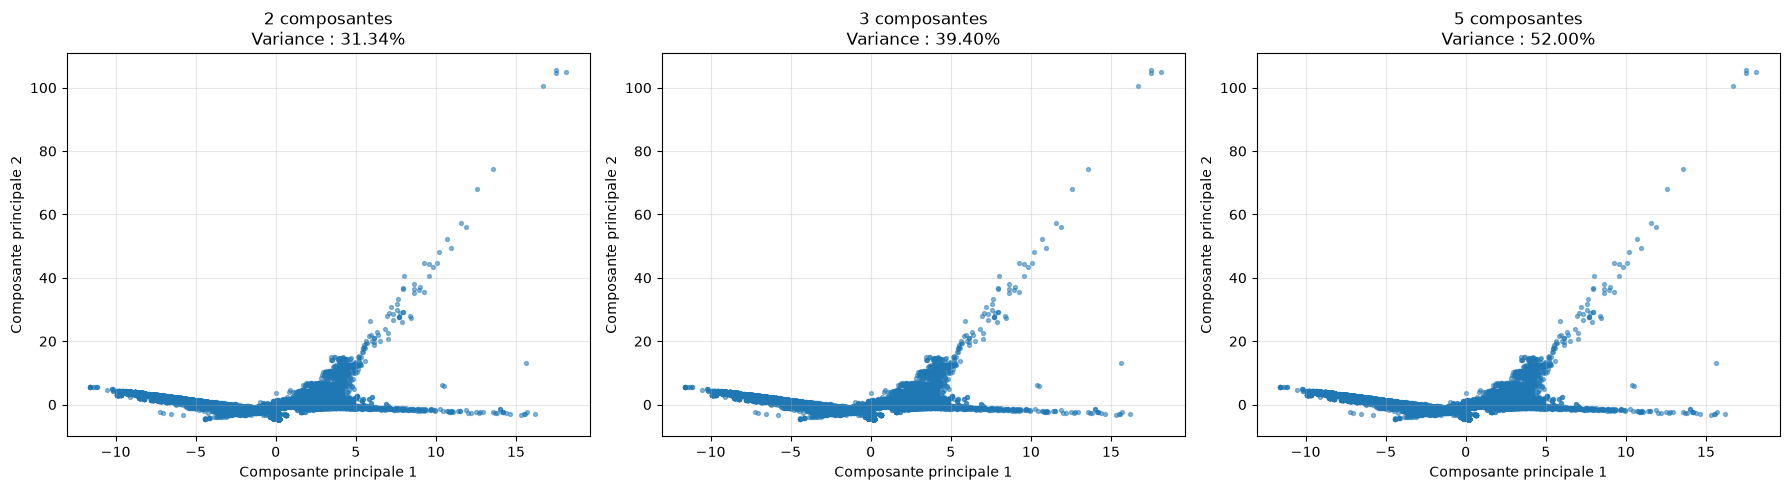

In [9]:
from sklearn.decomposition import PCA
from helper import plot_pca_scatter

import matplotlib.pyplot as plt

# Choisissez les trois dimensions à comparer
components_to_test = [2, 3, 5]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, n in zip(axes, components_to_test):
    pca = PCA(n_components=n, random_state=42)
    X_pca_current = pca.fit_transform(features)
    variance_pct = pca.explained_variance_ratio_.sum() * 100
    ax.scatter(
        X_pca_current[:, 0],
        X_pca_current[:, 1],
        s=8,
        alpha=0.5
    )
    ax.set_title(f"{n} composantes\nVariance : {variance_pct:.2f}%")
    ax.set_xlabel("Composante principale 1")
    ax.set_ylabel("Composante principale 2")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Composante 1 : 22.5513% de variance expliquée (cumul : 22.5513%)
Composante 2 : 8.7845% de variance expliquée (cumul : 31.3358%)
Composante 3 : 8.0625% de variance expliquée (cumul : 39.3983%)
Composante 4 : 6.8774% de variance expliquée (cumul : 46.2757%)
Composante 5 : 5.7280% de variance expliquée (cumul : 52.0037%)


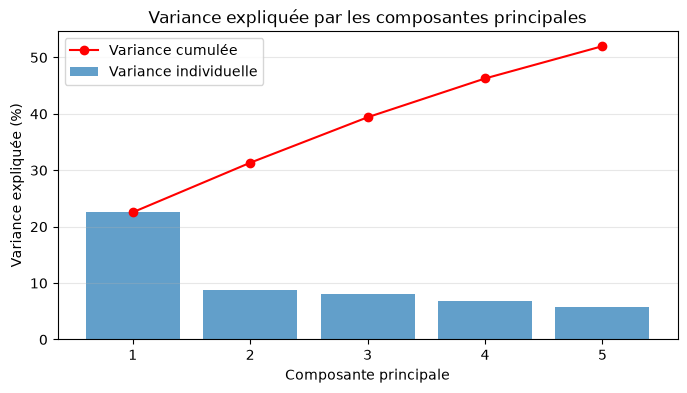

In [10]:
# Chaque composante principale est une combinaison linéaire des variables initiales.
# La variance expliquée mesure la proportion d'information conservée par chaque composante.

variance = pca.explained_variance_ratio_ * 100
variance_cumulee = variance.cumsum()

for i, (v, vc) in enumerate(zip(variance, variance_cumulee), start=1):
    print(
        f"Composante {i} : {v:.4f}% de variance expliquée "
        f"(cumul : {vc:.4f}%)"
    )

# Visualisation de la variance expliquée
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(variance) + 1), variance, alpha=0.7, label="Variance individuelle")
plt.plot(range(1, len(variance_cumulee) + 1), variance_cumulee, "o-", color="red",label="Variance cumulée")
plt.xlabel("Composante principale")
plt.ylabel("Variance expliquée (%)")
plt.title("Variance expliquée par les composantes principales")
plt.xticks(range(1, len(variance) + 1))
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.show()

In [11]:
# Variables contribuant le plus à chaque composante
for i, coefficients in enumerate(pca.components_, start=1):
    contributions = pd.Series(coefficients, index=data.columns)
    principales = contributions.abs().sort_values(ascending=False).head(5)
    print(f"\nComposante {i} — variables principales :")
    print(principales.index.tolist())


Composante 1 — variables principales :
['dwin', 'ct_srv_dst', 'ct_srv_src', 'ct_dst_src_ltm', 'swin']

Composante 2 — variables principales :
['dpkts', 'dloss', 'dbytes', 'dmean', 'spkts']

Composante 3 — variables principales :
['tcprtt', 'ackdat', 'synack', 'dttl', 'dpkts']

Composante 4 — variables principales :
['sbytes', 'sloss', 'spkts', 'sttl', 'dload']

Composante 5 — variables principales :
['dbytes', 'dloss', 'dpkts', 'sloss', 'sbytes']


# À faire :
1. Remplacez `RobustScaler()` par `StandardScaler()`. Que remarquez-vous sur la forme du nuage de points ?

C:\Users\Lucas\AppData\Local\Temp\ipykernel_32348\1305630963.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in features_encoded.select_dtypes(include=["object"]).columns:


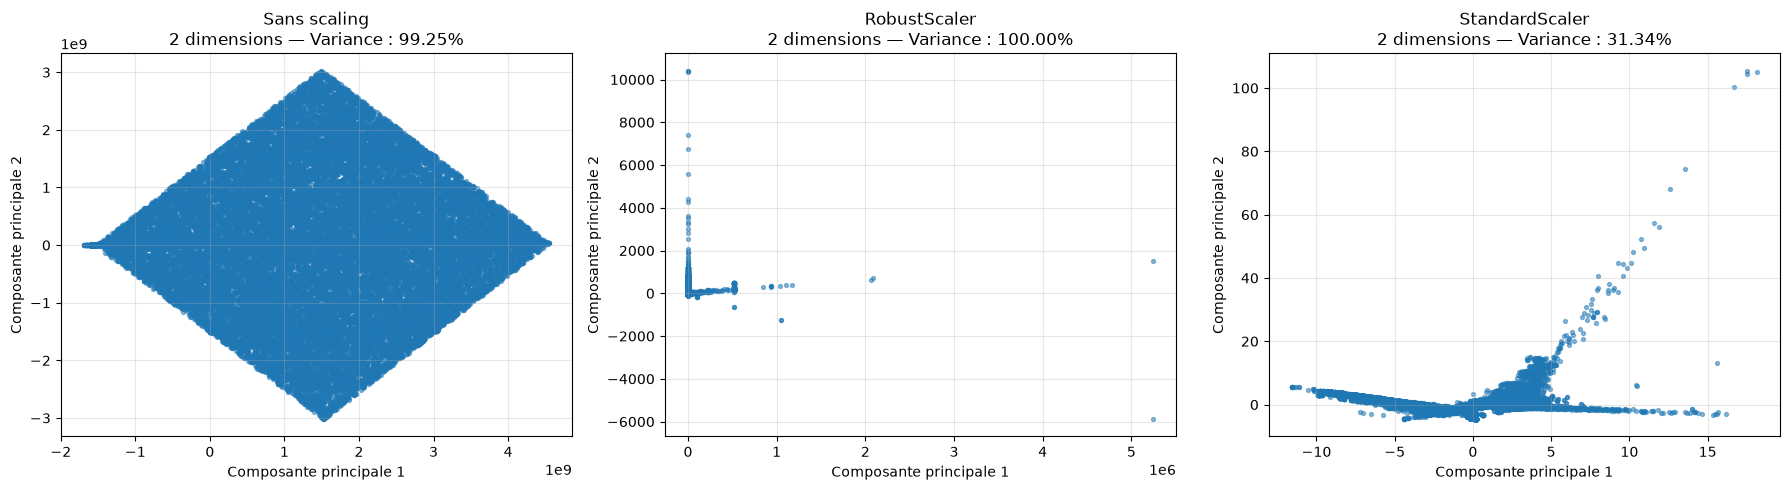

In [12]:
# Dimension choisie pour la PCA
d = 2  # Modifiez cette valeur

if d < 2:
    raise ValueError("d doit être supérieur ou égal à 2.")

# Reconstituer les données encodées avant normalisation
features_encoded = data.copy()
for col in features_encoded.select_dtypes(include=["object"]).columns:
    features_encoded[col] = LabelEncoder().fit_transform(
        features_encoded[col].astype(str)
    )

scaling_methods = {
    "Sans scaling": features_encoded,
    "RobustScaler": RobustScaler().fit_transform(features_encoded),
    "StandardScaler": StandardScaler().fit_transform(features_encoded),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, X) in zip(axes, scaling_methods.items()):
    pca_model = PCA(n_components=d, random_state=42)
    X_pca = pca_model.fit_transform(X)
    variance = pca_model.explained_variance_ratio_.sum() * 100

    ax.scatter(X_pca[:, 0], X_pca[:, 1], s=8, alpha=0.5)
    ax.set_title(f"{name}\n{d} dimensions — Variance : {variance:.2f}%")
    ax.set_xlabel("Composante principale 1")
    ax.set_ylabel("Composante principale 2")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

*NOTES*
S'il y a bcp de variance on pourrait avoir bcp de résultats avec de l'IA (Mais non on va voir)
On peut également analyser manuellement les anomalies 

2. faites fonctionner le code suivant. Qu'était la meilleure méthode finalement?

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from tqdm import tqdm

# Exclusion des variables cibles pour éviter la fuite de données
X_df = data.drop(columns=["label", "attack_cat"])
X_df = pd.get_dummies(X_df, dtype=float)
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.2, random_state=42, stratify=y)

scalers = {
    "Sans normalisation": None,
    "RobustScaler": RobustScaler(),
    "StandardScaler": StandardScaler()
}

results = []

for scaling_name, scaler_model in tqdm(scalers.items()):
    # Normalisation ajustée uniquement sur les données d'entraînement
    if scaler_model is None:
        X_train_scaled = X_train.to_numpy()
        X_test_scaled = X_test.to_numpy()
    else:
        X_train_scaled = scaler_model.fit_transform(X_train)
        X_test_scaled = scaler_model.transform(X_test)

    for use_pca in [False, True]:
        if use_pca:
            pca_model = PCA(n_components=0.99, random_state=42)
            X_train_final = pca_model.fit_transform(X_train_scaled)
            X_test_final = pca_model.transform(X_test_scaled)
            dimension = X_train_final.shape[1]
        else:
            X_train_final = X_train_scaled
            X_test_final = X_test_scaled
            dimension = X_train_final.shape[1]

        model = RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        )
        model.fit(X_train_final, y_train)
        predictions = model.predict(X_test_final)

        results.append({
            "Normalisation": scaling_name,
            "PCA": "Oui" if use_pca else "Non",
            "Dimensions": dimension,
            "Accuracy": accuracy_score(y_test, predictions),
            "Balanced accuracy": balanced_accuracy_score(y_test, predictions),
            "F1-score": f1_score(y_test, predictions, average="weighted")
        })

results_df = pd.DataFrame(results)
results_df.sort_values("F1-score", ascending=False)

100%|██████████| 3/3 [00:10<00:00,  3.35s/it]


,Normalisation,PCA,Dimensions,Accuracy,Balanced accuracy,F1-score
4,StandardScaler,Non,191,0.997510,0.997379,0.997510
0,Sans normalisation,Non,191,0.997449,0.997286,0.997449
2,RobustScaler,Non,191,0.997389,0.997219,0.997388
5,StandardScaler,Oui,165,0.990830,0.990617,0.990829
1,Sans normalisation,Oui,2,0.813688,0.814827,0.814088
3,RobustScaler,Oui,1,0.774579,0.779190,0.775090


Travail à faire:
Isoler les anomalies, et expliquer pourquoi vous pensez que c'est des anomalies. Vous devez faire le code vous même.

In [14]:
position = -1

print("Coordonnées PCA du premier point :")
print(X_pca_current[position])

print("\nLigne correspondante du jeu de données :")
display(data.iloc[position])

Coordonnées PCA du premier point :
[-0.45837455 -1.95686426 -1.67198255  0.16817083  0.23999043]

Ligne correspondante du jeu de données :


id                         82332
dur                     0.000009
proto                        udp
service                        -
state                        INT
spkts                          2
dpkts                          0
sbytes                       104
dbytes                         0
rate                 111111.1072
sttl                         254
dttl                           0
sload                 46222220.0
dload                        0.0
sloss                          0
dloss                          0
sinpkt                     0.009
dinpkt                       0.0
sjit                         0.0
djit                         0.0
swin                           0
stcpb                          0
dtcpb                          0
dwin                           0
tcprtt                       0.0
synack                       0.0
ackdat                       0.0
smean                         52
dmean                          0
trans_depth                    0
response_b

Variance statistique ne veut pas dire performance en AI

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from tqdm import tqdm

# Exclusion des variables cibles pour éviter la fuite de données
X_df = data.drop(columns=["label", "attack_cat"])
X_df = pd.get_dummies(X_df, dtype=float)
y = data["attack_cat"]

X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.2, random_state=42, stratify=y)

scalers = {
    "Sans normalisation": None,
    "RobustScaler": RobustScaler(),
    "StandardScaler": StandardScaler()
}

results = []

for scaling_name, scaler_model in tqdm(scalers.items()):
    # Normalisation ajustée uniquement sur les données d'entraînement
    if scaler_model is None:
        X_train_scaled = X_train.to_numpy()
        X_test_scaled = X_test.to_numpy()
    else:
        X_train_scaled = scaler_model.fit_transform(X_train)
        X_test_scaled = scaler_model.transform(X_test)

    for use_pca in [False, True]:
        if use_pca:
            pca_model = PCA(n_components=0.99, random_state=42)
            X_train_final = pca_model.fit_transform(X_train_scaled)
            X_test_final = pca_model.transform(X_test_scaled)
            dimension = X_train_final.shape[1]
        else:
            X_train_final = X_train_scaled
            X_test_final = X_test_scaled
            dimension = X_train_final.shape[1]

        model = RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        )
        model.fit(X_train_final, y_train)
        predictions = model.predict(X_test_final)

        results.append({
            "Normalisation": scaling_name,
            "PCA": "Oui" if use_pca else "Non",
            "Dimensions": dimension,
            "Accuracy": accuracy_score(y_test, predictions),
            "Balanced accuracy": balanced_accuracy_score(y_test, predictions),
            "F1-score": f1_score(y_test, predictions, average="weighted")
        })

results_df = pd.DataFrame(results)
results_df.sort_values("F1-score", ascending=False)

100%|██████████| 3/3 [00:11<00:00,  3.76s/it]


,Normalisation,PCA,Dimensions,Accuracy,Balanced accuracy,F1-score
0,Sans normalisation,Non,191,0.887593,0.559820,0.888490
2,RobustScaler,Non,191,0.887168,0.569718,0.888083
4,StandardScaler,Non,191,0.886925,0.547395,0.887731
5,StandardScaler,Oui,165,0.864638,0.497011,0.866110
1,Sans normalisation,Oui,2,0.627619,0.387978,0.657152
3,RobustScaler,Oui,1,0.505010,0.315812,0.512550


In [16]:
import plotly.express as px
from sklearn.decomposition import PCA

# 1. Calcul PCA 3D
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(features)

# 2. Graphique interactif
fig = px.scatter_3d(
    x=X_pca_3d[:, 0],
    y=X_pca_3d[:, 1],
    z=X_pca_3d[:, 2],
    color=data["label"].astype(str),
    labels={"x": "PC 1", "y": "PC 2", "z": "PC 3"},
    title="Visualisation PCA 3D interactive",
    opacity=0.7,
)

fig.update_traces(marker=dict(size=4))
fig.show(renderer="browser")